In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.gaussian_process.kernels import (
    WhiteKernel, ConstantKernel, RBF, RationalQuadratic, ExpSineSquared, DotProduct
)
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm

from data_loader import BondDataLoader
from src.feature_manager_sim import FeatureManagerSim
from src.feature_manager import FeatureManager
from walk_forward import WalkForwardValidator
from kernel_ridge_models import KernelRidgeEnsemble
# import time
import time

## Exploratory Data Analysis
- Normalize the FRED data containing the DGS index yields and predictor variables
- Define the training, validation, and test periods
- Analyze the relationship between our predictor and target variables

In [2]:
# get the target, actual, and feature columns
feature_manager = FeatureManagerSim(features_config_path='data/features_selected4.yaml')
feature_manager2 = FeatureManager(features_config_path='data/features_selected3.yaml')

independent_variables_7_day = feature_manager2.get_features_for_time_pred(time_prediction='seven-day-ahead')
dependent_variables_7_day = feature_manager.get_dependent_variables(time_prediction='seven-day-ahead')

independent_variables_30_day = feature_manager2.get_features_for_time_pred(time_prediction='thirty-day-ahead')
dependent_variables_30_day = feature_manager.get_dependent_variables(time_prediction='thirty-day-ahead')

independent_variables_60_day = feature_manager2.get_features_for_time_pred(time_prediction='sixty-day-ahead')
dependent_variables_60_day = feature_manager.get_dependent_variables(time_prediction='sixty-day-ahead')


dependent_variables_7_day = [f"{x}_future_val" for x in dependent_variables_7_day]
dependent_variables_30_day = [f"{x}_future_val" for x in dependent_variables_30_day]
dependent_variables_60_day = [f"{x}_future_val" for x in dependent_variables_60_day]


actuals_variables = feature_manager.get_actual_variables()

# print the outputs
print('################################### Seven-Day-Ahead ###################################')
print(f"Independent variables: {independent_variables_7_day}")
print(f"Dependent variables: {dependent_variables_7_day}")
print(f"\n")
print('################################### Thirty-Day-Ahead ###################################')
print(f"Independent variables: {independent_variables_30_day}")
print(f"Dependent variables: {dependent_variables_30_day}")
print(f"\n")
print('################################### Sixty-Day-Ahead ###################################')
print(f"Independent variables: {independent_variables_60_day}")
print(f"Dependent variables: {dependent_variables_60_day}")
print(f"\n")
print(f"Actual variables: {actuals_variables}")
# get the raw factor data

# check if the actuals and the raw_ids are in the data
# # load in the raw factor data
# raw_data = pd.read_parquet('../data/fred_prorcessed_daily.parquet')
# set(raw_ids + actuals_variables) - set(raw_data.columns.tolist())

INFO:src.feature_manager_sim:Loaded features for 6 future time predictions
INFO:src.feature_manager_sim:Available time predictions: ['thirty-day-ahead', 'current_values', 'sixty-day-ahead', 'seven-day-ahead', 'one-day-ahead', 'future_values']
INFO:src.feature_manager:Loaded features for 5 future time predictions
INFO:src.feature_manager:Available time predictions: ['thirty-day-ahead', 'sixty-day-ahead', 'dependent_variables', 'seven-day-ahead', 'one-day-ahead']
INFO:src.feature_manager:Retrieved 19 features for seven-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 dependent variables for seven-day-ahead
INFO:src.feature_manager:Retrieved 23 features for thirty-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 dependent variables for thirty-day-ahead
INFO:src.feature_manager:Retrieved 22 features for sixty-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 dependent variables for sixty-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 actual variables


################################### Seven-Day-Ahead ###################################
Independent variables: ['U6RATE', 'MEDCPIM157SFRBCLE_moving_avg_60', 'STICKCPIM158SFRBATL_moving_avg_60', 'DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30', 'REAINTRATREARAT1YE_moving_avg_60', 'REAINTRATREARAT1YE_exp_moving_avg_60', 'MEDCPIM157SFRBCLE_exp_moving_avg_60', 'U6RATE_exp_moving_avg_60', 'EFFR_exp_moving_avg_30']
Dependent variables: ['DGS1MO_future_val', 'DGS3MO_future_val', 'DGS6MO_future_val', 'DGS1_future_val', 'DGS2_future_val', 'DGS3_future_val', 'DGS5_future_val', 'DGS7_future_val', 'DGS10_future_val', 'DGS20_future_val', 'DGS30_future_val']


################################### Thirty-Day-Ahead ###################################
Independent variables: ['U6RATE', 'MEDCPIM157SFRBCLE_moving_avg_60', 'STICKCPIM158SFRBATL_moving_avg_60', 'DGS5', 'DGS7', 'DGS10', 'DGS3', 'DGS3MO', 'DGS1', 'DGS30', 'REAINTRATREARAT1YE_moving_avg_60', 'DGS2',

## Risk Modeling Data

Data is devised into three time horizon sets. Those sets are the seven, thirty, and sixty day ahead forecasts. Our target variables, the DGS values mentioned in the below section makes the forecasting a multivariate prolem. Each record records our predictor variables at the current time, t. To make the forecasting possible each target variable is shifted back by m, where $m \in A$. $A$ = {7, 30, 60}. At time t the value for the dependent/target variable becomes the value of that variable at time t+m. Information on the predictor variables and the dependent variables are listed as the following.

### Dependent Variables
- DGS* : The index yields. There are 11 yields which ranges from 1 month to 30 years

### Independent Variables

| Variable ID | Description | Used for Forecasts |
|-------------|-------------|--------------------|
| U6RATE | Total Unemployed, Plus All Personas | 7, 30, 60          |
| MEDCPIM157SFRBCLE_moving_avg_60 | 60 day moving Average of Median Consumer Price Index | 7, 30, 60          |
| STICKCPIM158SFRBATL_moving_avg_60 | 60 day moving Average of Sticky Price Consumer Price Index | 7, 30, 60          |
| DGS1MO | 1-Month Treasury Constant Maturity Rate | 7, 30, 60          |
| REAINTRATREARAT1YE_moving_avg_60 | 60 day moving average of 1-Year Real Interest Rate | 7, 30, 60          |
| REAINTRATREARAT1YE_exp_moving_avg_60 | 60 day exponential moving average of 1-Year Real Interest Rate | 7, 30, 60          |
| MEDCPIM157SFRBCLE_exp_moving_avg_60 | 60 day exponential moving Average of Median Consumer Price Index | 7, 30, 60          |
| U6RATE_exp_moving_avg_60 | 60 day exponential moving average of Total Unemployed, Plus All Personas | 7, 30, 60          |
| EFFR_exp_moving_avg_30 | 30 day exponential moving average of Effective Federal Funds Rate | 7                  |
| REAINTRATREARAT1YE_exp_moving_avg_30 | 30 day exponential moving average of 1-Year Real Interest Rate | 30, 60             |
| 2yr_10yr_spread_exp_moving_avg_30 | 30 day exponential moving average of 2-Year to 10-Year Treasury Spread | 30, 60             |
| EXPINF30YR_exp_moving_avg_60 | 60 day exponential moving average of 30-Year Expected Inflation | 30, 60             |
| EFFR_exp_moving_avg_60 | 60 day exponential moving average of Effective Federal Funds Rate | 30, 60             |
| T10Y2Y_exp_moving_avg_60 | 60 day exponential moving average of 10-Year Treasury minus 2-Year Treasury | 30, 60             |
| MTSDS133FMS_exp_moving_avg_60 | 60 day exponential moving average of Moody's Seasoned Aaa Corporate Bond Yield relative to yield on 10-Year Treasury | 30, 60             |
| T10Y3M_exp_moving_avg_60 | 60 day exponential moving average of 10-Year Treasury minus 3-Month Treasury | 60                 |

### Persisted data

- data/kernel_regression_train_shifted_7_.parquet
- data/kernel_regression_train_shifted_30_.parquet
- data/kernel_regression_train_shifted_60_.parquet


In [3]:
# load in the data
df_7_day = pd.read_parquet('data/kernel_regression_train_shifted_7_.parquet')
df_30_day = pd.read_parquet('data/kernel_regression_train_shifted_30_.parquet')
df_60_day = pd.read_parquet('data/kernel_regression_train_shifted_60_.parquet')

df_7_day = df_7_day[df_7_day.index.to_timestamp() >= pd.to_datetime('2006-01-01')]
df_30_day = df_30_day[df_30_day.index.to_timestamp() >= pd.to_datetime('2006-01-01')]
df_60_day = df_60_day[df_60_day.index.to_timestamp() >= pd.to_datetime('2006-01-01')]

# split into training validation and test sets
df_7_day_train = df_7_day[(df_7_day.index.to_timestamp() < pd.to_datetime('2018-01-01')) & (df_7_day.index.to_timestamp() >= pd.to_datetime('2011-01-01'))]
df_30_day_train = df_30_day[(df_30_day.index.to_timestamp() < pd.to_datetime('2018-01-01')) & (df_30_day.index.to_timestamp() >= pd.to_datetime('2011-01-01'))]
df_60_day_train = df_60_day[(df_60_day.index.to_timestamp() < pd.to_datetime('2018-01-01')) & (df_60_day.index.to_timestamp() >= pd.to_datetime('2011-01-01'))]

# Split the training into analysis and validation sets
df_7_day_analysis = df_7_day_train.iloc[:1500]
df_7_day_validation = df_7_day_train.iloc[1500:]

df_30_day_analysis = df_30_day_train.iloc[:1500]
df_30_day_validation = df_30_day_train.iloc[1500:]

df_60_day_analysis = df_60_day_train.iloc[:1500]
df_60_day_validation = df_60_day_train.iloc[1500:]


### Objective

The premise is to forecast the index yields 7, 30, and 60 days out. By knowing the range of where index yields will be in the future this will then inform the beliefs of an investor to make a decision as to balance their portfolio to maximize returns and mitigate risks.

The predictor variables were selected based on subjective knowldege as to what impacts Governmental index yields. The below, explores this relationship even further.

- Evaluate correlations between independent and dependent variables
- Explore non-linear relationships between independent and dependent variables
- Apply different kernels


In [4]:
# scale the data
scaler_y_7 = StandardScaler()
scaler_y_30 = StandardScaler()
scaler_y_60 = StandardScaler()

scaler_x_7 = StandardScaler()
scaler_x_30 = StandardScaler()
scaler_x_60 = StandardScaler()

# remove EFFR_exp_moving_avg_30 from independent variables
independent_variables_7_day.remove('EFFR_exp_moving_avg_30') # TODO Make sure to comment this out
df_7_day_analysis[independent_variables_7_day] = scaler_x_7.fit_transform(df_7_day_analysis[independent_variables_7_day])
df_7_day_analysis[dependent_variables_7_day] = scaler_y_7.fit_transform(df_7_day_analysis[dependent_variables_7_day])


df_30_day_analysis[independent_variables_30_day] = scaler_x_30.fit_transform(df_30_day_analysis[independent_variables_30_day])
df_30_day_analysis[dependent_variables_30_day] = scaler_y_30.fit_transform(df_30_day_analysis[dependent_variables_30_day])

df_60_day_analysis[independent_variables_60_day] = scaler_x_60.fit_transform(df_60_day_analysis[independent_variables_60_day])
df_60_day_analysis[dependent_variables_60_day] = scaler_y_60.fit_transform(df_60_day_analysis[dependent_variables_60_day])

transformed_cols = independent_variables_7_day + dependent_variables_7_day
df_7_day_analysis[transformed_cols].describe()

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_89375/955511914.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_7_day_analysis[independent_variables_7_day] = scaler_x_7.fit_transform(df_7_day_analysis[independent_variables_7_day])
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_89375/955511914.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_7_day_analysis[dependent_variables_7_day] = scaler_y_7.fit_transform(df_7_day_analysis[dependent_variables_7_day])
/var/folders/h3/

,U6RATE,MEDCPIM157SFRBCLE_moving_avg_60,STICKCPIM158SFRBATL_moving_avg_60,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,...,DGS3MO_future_val,DGS6MO_future_val,DGS1_future_val,DGS2_future_val,DGS3_future_val,DGS5_future_val,DGS7_future_val,DGS10_future_val,DGS20_future_val,DGS30_future_val
count,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,...,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03
mean,5.305386e-16,-8.337035e-16,3.789561e-17,-2.652693e-16,-1.894781e-16,-4.168517e-16,-7.579123e-17,7.579123e-17,-9.473903e-17,3.221127e-16,...,-2.273737e-16,-4.168517e-16,-7.579123e-17,3.979039e-16,1.136868e-16,-1.326346e-16,-2.652693e-16,-3.410605e-16,-3.505344e-16,5.684342e-17
std,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,...,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00
min,-2.056759e+00,-2.962346e+00,-3.214820e+00,-1.146087e+00,-1.570287e+00,-1.859981e+00,-1.483241e+00,-1.495149e+00,-1.309336e+00,-1.537072e+00,...,-1.567711e+00,-1.869015e+00,-1.496310e+00,-1.494306e+00,-1.309716e+00,-1.540574e+00,-1.693135e+00,-1.719566e+00,-1.752125e+00,-2.046396e+00
25%,-8.744619e-01,-6.722049e-01,-5.863764e-01,-6.332966e-01,-7.286612e-01,-8.614230e-01,-8.739123e-01,-7.400923e-01,-9.185887e-01,-9.568505e-01,...,-7.185656e-01,-8.583726e-01,-8.793598e-01,-7.399757e-01,-9.187558e-01,-9.570671e-01,-8.806841e-01,-8.022344e-01,-7.374910e-01,-7.300331e-01
50%,2.421519e-01,-1.127475e-01,-8.218632e-03,-3.769012e-01,-1.675771e-01,-1.125042e-01,-2.645839e-01,-3.282435e-01,-1.370932e-01,1.821037e-01,...,-1.524687e-01,-1.003905e-01,-2.624095e-01,-3.285225e-01,-1.368360e-01,1.883360e-01,1.773914e-01,-1.376372e-01,-2.323326e-01,-2.546797e-01
75%,7.019341e-01,5.744827e-01,5.710812e-01,3.922849e-01,6.740490e-01,8.860541e-01,5.478539e-01,4.954541e-01,8.575373e-01,8.053051e-01,...,6.966765e-01,9.102522e-01,5.601908e-01,4.943838e-01,8.583348e-01,7.934546e-01,7.300469e-01,6.767285e-01,6.139157e-01,5.863301e-01
max,1.555815e+00,2.456175e+00,2.702662e+00,7.058564e+00,2.918385e+00,2.383892e+00,3.188277e+00,3.378396e+00,2.704708e+00,2.417033e+00,...,2.961064e+00,2.426216e+00,3.233642e+00,3.374556e+00,2.706509e+00,2.435919e+00,2.482485e+00,2.623718e+00,2.600009e+00,2.542592e+00


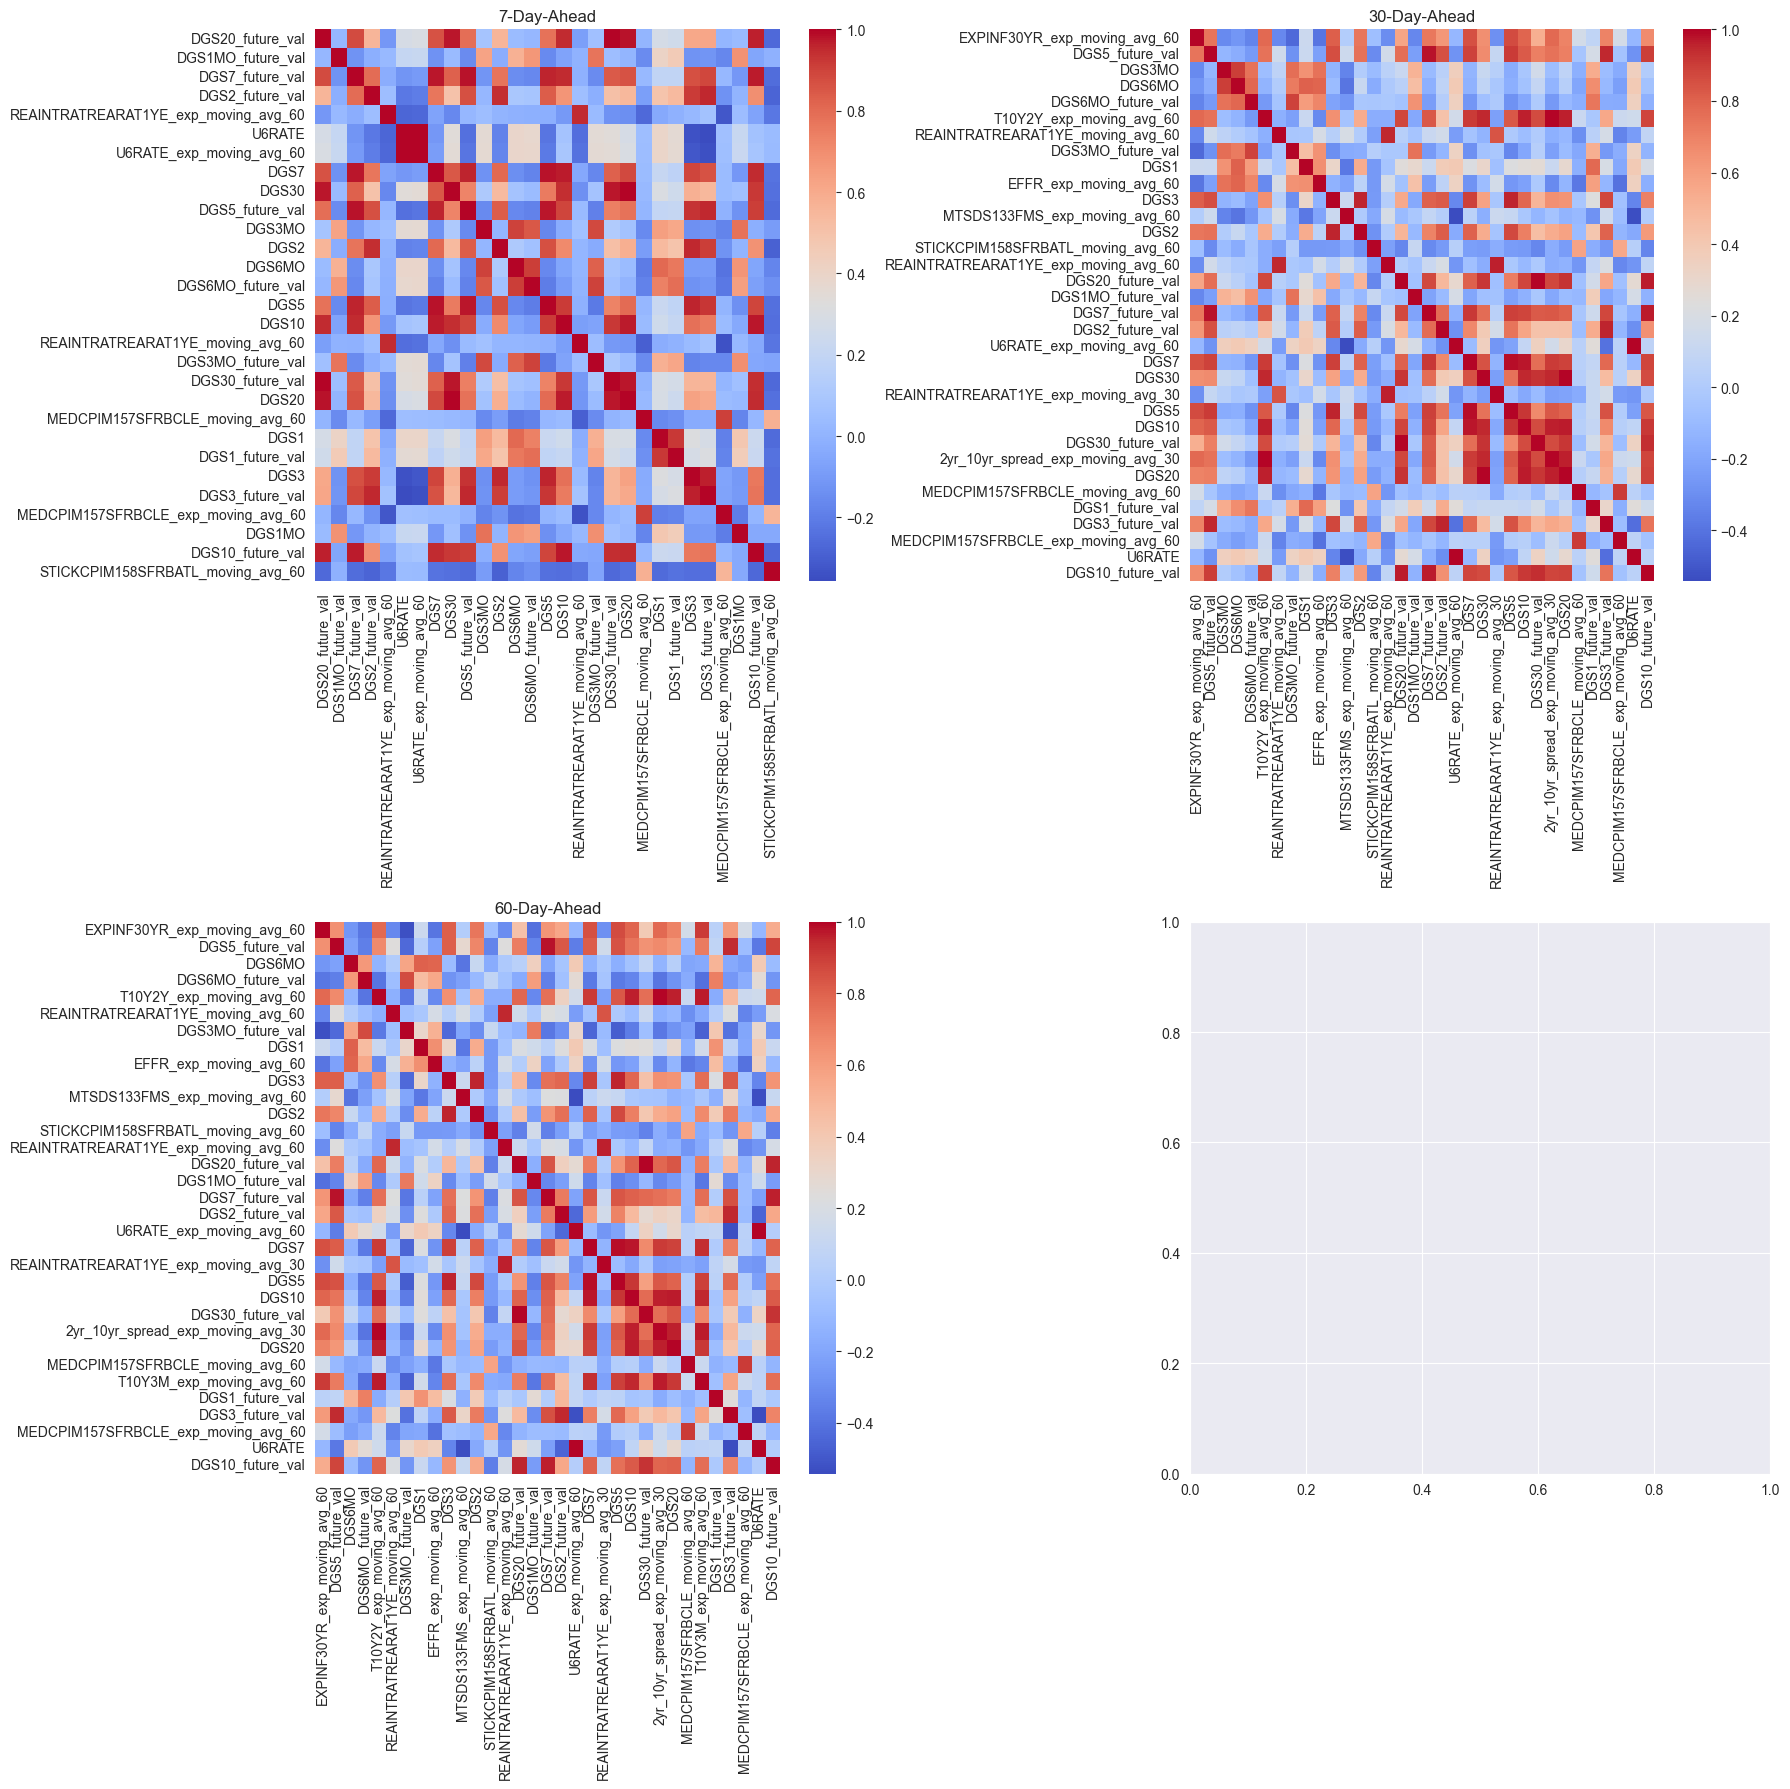

In [5]:
# make a full columns of the dependent variables and independent variables
full_columns_7 = list(set(dependent_variables_7_day).union(set(independent_variables_7_day)))
full_columns_30 = list(set(dependent_variables_30_day).union(set(independent_variables_30_day)))
full_columns_60 = list(set(dependent_variables_60_day).union(set(independent_variables_60_day)))

# plot a 2 by 2 grid displaying the correlation matrices of the different forecasting horizons
fig, axes = plt.subplots(2, 2, figsize=(18, 18))
axes = axes.flatten()
titles = ['7-Day-Ahead', '30-Day-Ahead', '60-Day-Ahead']
data_list = [df_7_day_analysis, df_30_day_analysis, df_60_day_analysis]
full_columns_list = [full_columns_7, full_columns_30, full_columns_60]
for i, data in enumerate(data_list):
    sns.heatmap(data[full_columns_list[i]].corr(), annot=False, fmt='.2f', ax=axes[i], cmap='coolwarm')
    axes[i].set_title(titles[i])
plt.tight_layout()
plt.show()


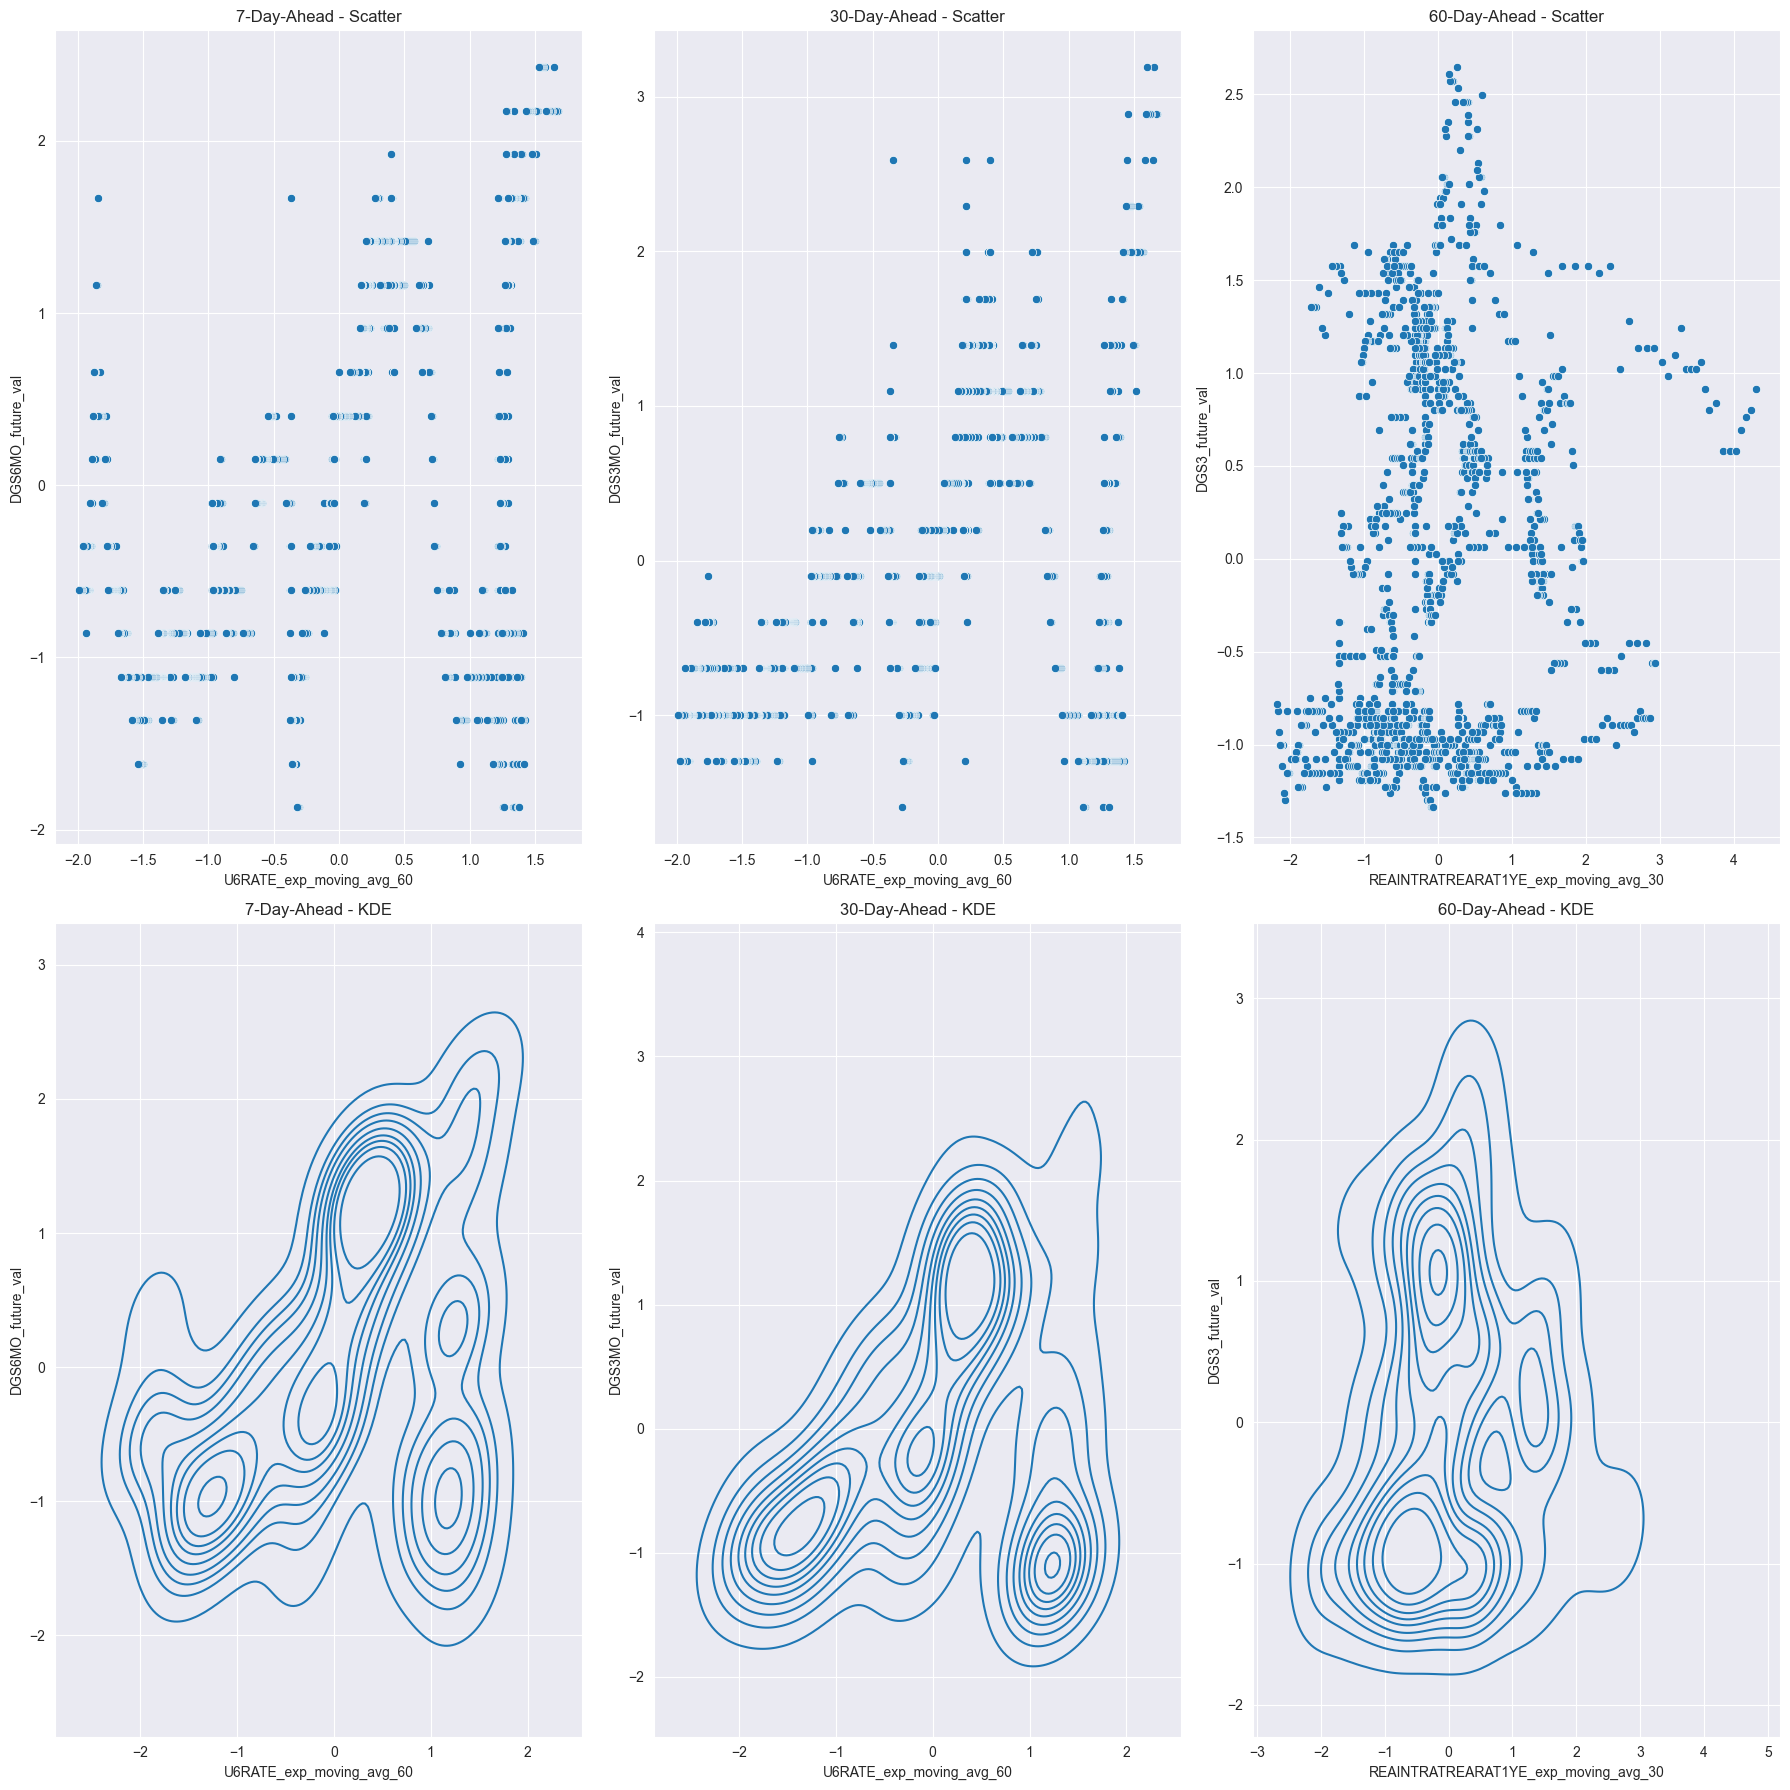

In [6]:
# Plot the joint distribution of an independent variable and dependent variable with high correlation for the three horizons
seven_day_ahead_set = ['U6RATE_exp_moving_avg_60', 'DGS6MO_future_val']
thirty_day_ahead_set = ['U6RATE_exp_moving_avg_60', 'DGS3MO_future_val']
sixty_day_ahead_set = ['REAINTRATREARAT1YE_exp_moving_avg_30', 'DGS3_future_val']

fig, axes = plt.subplots(2, 3, figsize=(18, 18))
axes = axes.flatten()
columns_list = [seven_day_ahead_set, thirty_day_ahead_set, sixty_day_ahead_set]
dfs_list = [df_7_day_analysis, df_30_day_analysis, df_60_day_analysis]
titles = ['7-Day-Ahead', '30-Day-Ahead', '60-Day-Ahead']
# counter = 0
for i, column_set in enumerate(columns_list):
    # Scatter plots in the first row (indices 0, 1, 2)
    sns.scatterplot(data=dfs_list[i], x=column_set[0], y=column_set[1], ax=axes[i])
    axes[i].set_title(f"{titles[i]} - Scatter")
    axes[i].set_xlabel(column_set[0])
    axes[i].set_ylabel(column_set[1])

    # KDE plots in the second row (indices 3, 4, 5)
    sns.kdeplot(data=dfs_list[i], x=column_set[0], y=column_set[1], ax=axes[i+3])
    axes[i+3].set_title(f"{titles[i]} - KDE")
    axes[i+3].set_xlabel(column_set[0])
    axes[i+3].set_ylabel(column_set[1])

plt.tight_layout()
plt.show()


#### EDA Report:

As seen displayed in the correlation heat map, the scatter plots, and joint distributions of the variables, there are distinguishable relationships amongst the dependent variables and the independent variables. There are also a number of highly correlated features.
The heat map displays many correlations. However, with the scatter plots and joint distributions we see linear functions that have similar movements to that of a sine function. Lastly, clusters reveal themselves with joint distributions between the independent and dependent variables.

Based on the analysis we need a modeling method that is flexible enough to capture the linear and non-linear relationships between the dependent and independent variables.

#### Kernels:

Kernels can be used to smooth data to capture non-linear relationships as well as linear ones. They do so by capturing relationships between all the observations within a dataset. Capturing those relationships can be through a linear function or a distance measure. Below are some common and explored kernels with their definitions and descriptions:

**Constant Kernel:**

$$k(x_1, x_2) = \text{constant\_value} \quad \forall x_1, x_2$$

Combined with other kernels as a constant term.

**White Kernel:**

$$k(x_i, x_j) = \text{noise\_level} \quad \text{if } x_i == x_j \text{ else } 0$$

Combined with other kernels as white noise. Good when modeling noisy processes.

**RBF (Radial Basis Function):**

$$k(x_i, x_j) = \exp\left(-\frac{d(x_i, x_j)^2}{2l^2}\right)$$

The radial basis function, also known as the squared exponential kernel. It is one of the more popular kernels to use given its ability to capture dynamic and non-linear relationships. The kernel is capable of doing so by leveraging the euclidean distance between points. One of the main parameters to this kernel is its length parameter $l$. This parameter handles the magnitude in the changes in the relationships between points.

**Rational Quadratic:**

$$k(x_i, x_j) = \left(1 + \frac{d(x_i, x_j)^2}{2\alpha l^2}\right)^{-\alpha}$$

An even more flexible kernel in capturing relationships, given it is an infinite sum of radial basis functions. Because it is an infinite sum, it can capture many time lengths.

**Dot Product:**

$$k(x_i, x_j) = \sigma_0^2 + x_i \cdot x_j$$

Captures linear relationships via ordinary least squares.

**Exp-Sine-Squared kernel:**

$$k(x_i, x_j) = \exp\left(-\frac{2\sin^2(\pi d(x_i, x_j)/p)}{l^2}\right)$$

A kernel that is good at finding repetitive patterns within data. Like RBF and Rational quadratic, this kernel uses a length parameter $l$ in the same manner. It is also followed up with periodicity $p$, which is the length in time between repeats.

Kernels are both multiplicative and additive. When you add two kernels together, you can find a combination of relationships. Adding finds relationships using an OR statement and multiplication is with an AND condition.

In [7]:
kernel_test = (ConstantKernel(1.0, (1e-3, 1e3)) *
               # DotProduct() *
               RBF(length_scale=1.5, length_scale_bounds=(1e-7, 1e7)) +
               WhiteKernel(noise_level=1e-5))

kernel_test2 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                # DotProduct() *
                RationalQuadratic(length_scale=1.0, alpha=0.1,
                                  length_scale_bounds=(1e-5, 1e5),
                                  alpha_bounds=(1e-5, 1e5)) +
                WhiteKernel(noise_level=1e-5))

kernel_test3 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                DotProduct() +
                RationalQuadratic(length_scale=1.0, alpha=0.1,
                                  length_scale_bounds=(1e-5, 1e5),
                                  alpha_bounds=(1e-5, 1e5)) +
                WhiteKernel(noise_level=1e-5))

kernel_test4 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                DotProduct() +
                ExpSineSquared(length_scale=2, periodicity=20.0,
                               length_scale_bounds=(0.01, 10),
                               periodicity_bounds=(1e-2, 1e2)) +
                WhiteKernel(noise_level=1e-5))

kernel_test5 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                # DotProduct() *
                ExpSineSquared(length_scale=2, periodicity=20.0,
                               length_scale_bounds=(0.01, 10),
                               periodicity_bounds=(1e-2, 1e2)) +
                WhiteKernel(noise_level=1e-5))

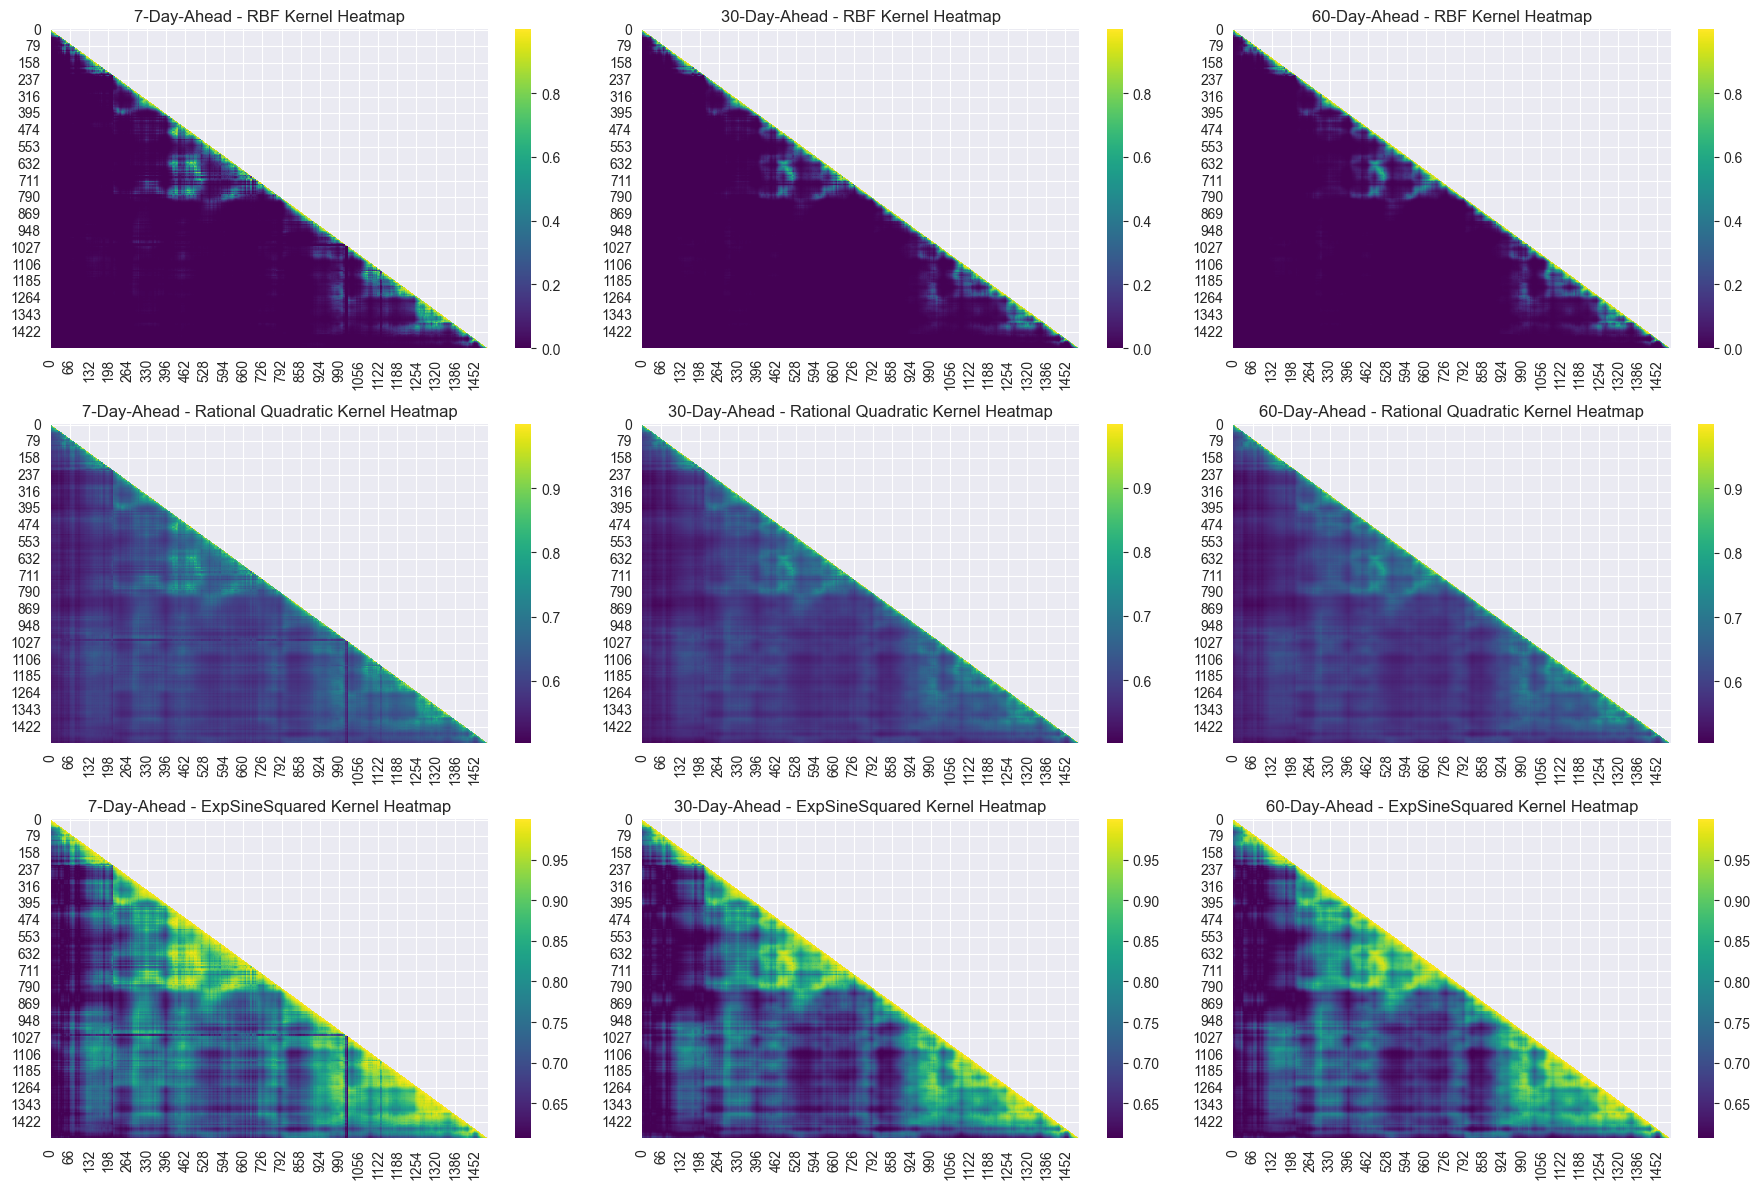

In [8]:
plot_variables = [
    [kernel_test, df_7_day_analysis[independent_variables_7_day], '7-Day-Ahead', 'RBF'],
    [kernel_test, df_30_day_analysis[independent_variables_30_day], '30-Day-Ahead', 'RBF'],
    [kernel_test, df_60_day_analysis[independent_variables_60_day], '60-Day-Ahead', 'RBF'],
    [kernel_test2, df_7_day_analysis[independent_variables_7_day], '7-Day-Ahead', 'Rational Quadratic'],
    [kernel_test2, df_30_day_analysis[independent_variables_30_day], '30-Day-Ahead', 'Rational Quadratic'],
    [kernel_test2, df_60_day_analysis[independent_variables_60_day], '60-Day-Ahead', 'Rational Quadratic'],
    [kernel_test5, df_7_day_analysis[independent_variables_7_day], '7-Day-Ahead', 'ExpSineSquared'],
    [kernel_test5, df_30_day_analysis[independent_variables_30_day], '30-Day-Ahead', 'ExpSineSquared'],
    [kernel_test5, df_60_day_analysis[independent_variables_60_day], '60-Day-Ahead', 'ExpSineSquared']
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, plot in enumerate(plot_variables):
    x_features = plot[1].to_numpy()
    xcov = plot[0](x_features, x_features)
    sns.heatmap(xcov, cmap='viridis', mask=np.triu(np.ones_like(xcov, dtype=bool)), cbar=True, ax=axes[i])
    axes[i].set_title(f"{plot[2]} - {plot[3]} Kernel Heatmap")

plt.tight_layout()
plt.show()

The x axis within the heatmaps represent the data points from 0 to 1500 days in our analysis datasets. The y axis represents those same points and the values are the kernel function values for the data points. Values near the diagnal are closer in time so we expect values to be closer together given the time dependent structure. However, because we are using a distance measure and a sinuadal function for our three kernels, we capture time periods with similar values that are not close in time. This is the ebes and flows of the market. ExpSineSquared is capturing dense regions of similarity, where Rational quadratic picks on some of the same datapoints but with a little less intensity. We can see how this compares to that of our target variables.

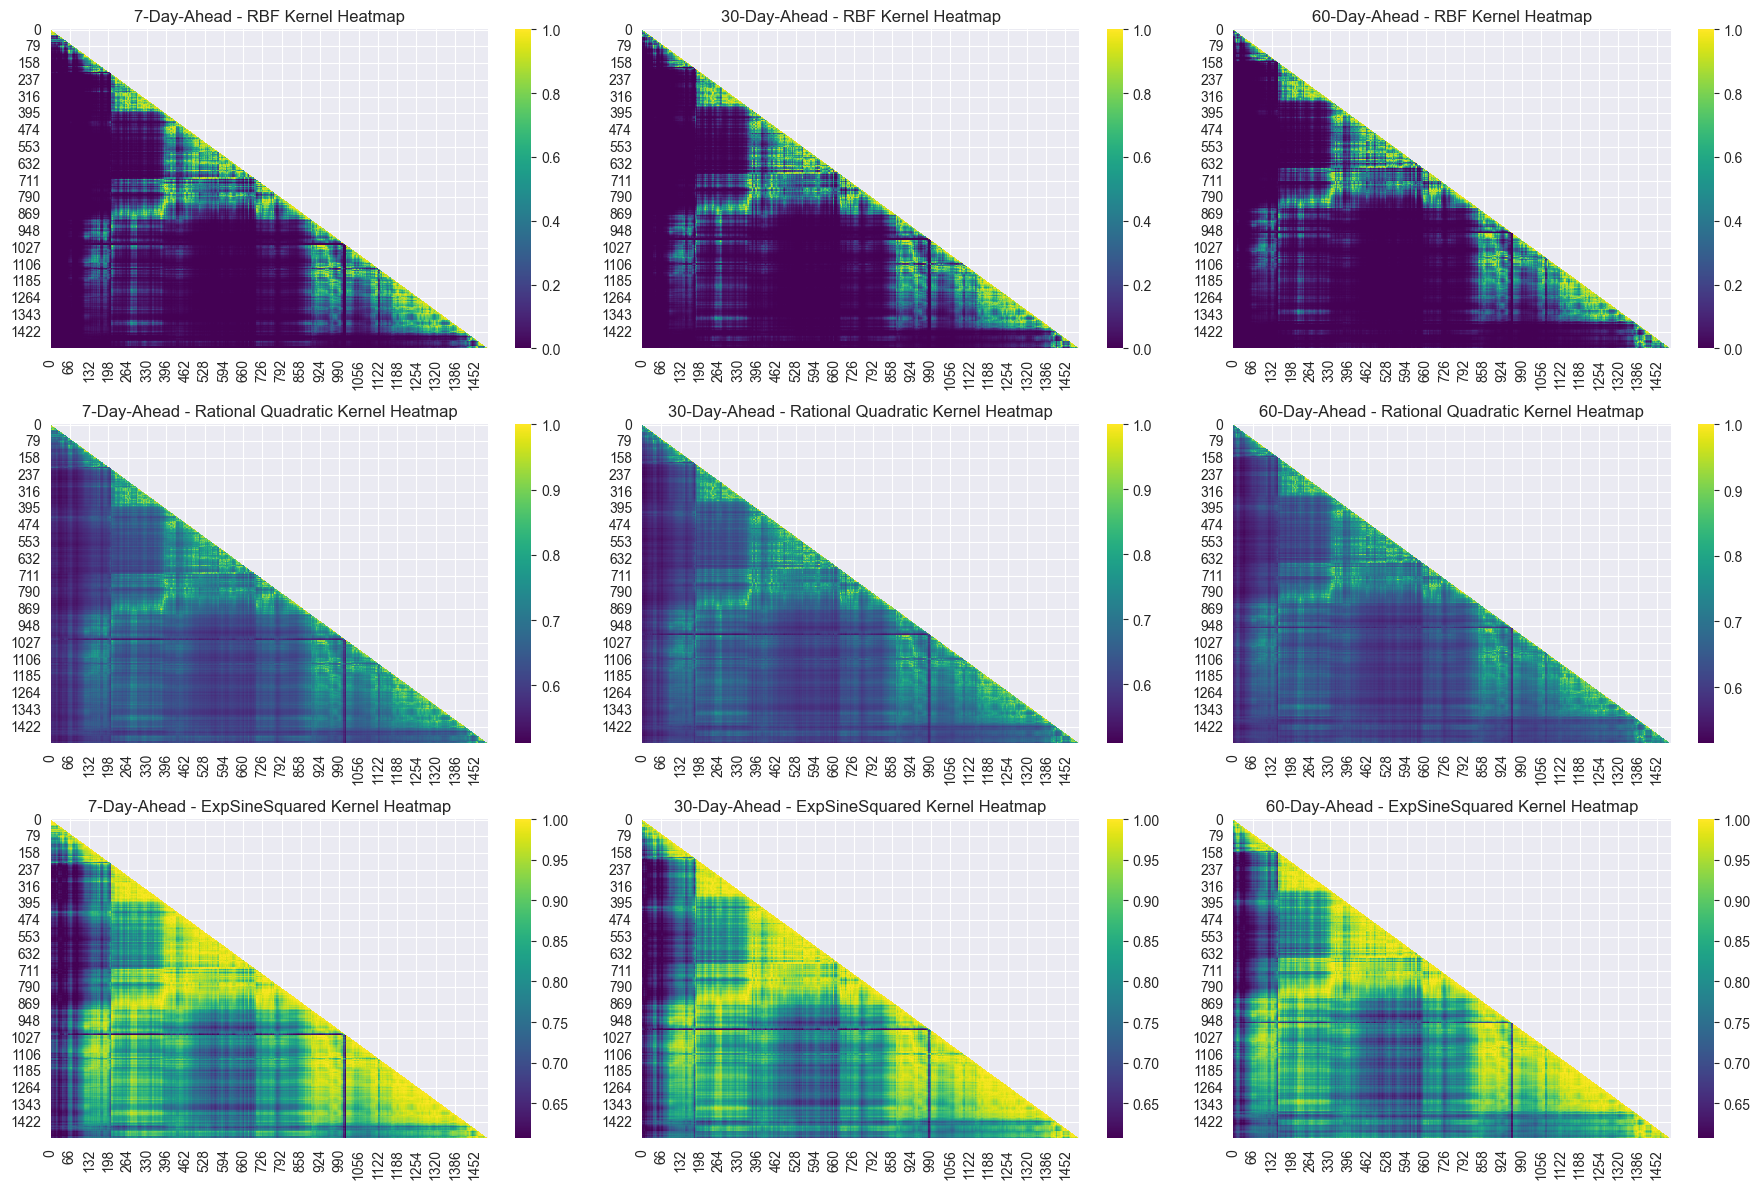

In [13]:
plot_variables = [
    [kernel_test, df_7_day_analysis[dependent_variables_7_day], '7-Day-Ahead', 'RBF'],
    [kernel_test, df_30_day_analysis[dependent_variables_30_day], '30-Day-Ahead', 'RBF'],
    [kernel_test, df_60_day_analysis[dependent_variables_60_day], '60-Day-Ahead', 'RBF'],
    [kernel_test2, df_7_day_analysis[dependent_variables_7_day], '7-Day-Ahead', 'Rational Quadratic'],
    [kernel_test2, df_30_day_analysis[dependent_variables_30_day], '30-Day-Ahead', 'Rational Quadratic'],
    [kernel_test2, df_60_day_analysis[dependent_variables_60_day], '60-Day-Ahead', 'Rational Quadratic'],
    [kernel_test5, df_7_day_analysis[dependent_variables_7_day], '7-Day-Ahead', 'ExpSineSquared'],
    [kernel_test5, df_30_day_analysis[dependent_variables_30_day], '30-Day-Ahead', 'ExpSineSquared'],
    [kernel_test5, df_60_day_analysis[dependent_variables_60_day], '60-Day-Ahead', 'ExpSineSquared']
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, plot in enumerate(plot_variables):
    x_features = plot[1].to_numpy()
    xcov = plot[0](x_features, x_features)
    sns.heatmap(xcov, cmap='viridis', mask=np.triu(np.ones_like(xcov, dtype=bool)), cbar=True, ax=axes[i])
    axes[i].set_title(f"{plot[2]} - {plot[3]} Kernel Heatmap")

plt.tight_layout()
plt.show()

The above graph are the distance measures of the kernel for the dependent variable. Kernels such as the RationalQuadratic and the ExpSineSqured kernels pick on some of the same similar patterns that were shown in the same kernles for the feature variables. In our initial analysis exploring the correlations between the variables we seen a number of highlly correlated features and features correlated with many of the dependent variables. Some of the kernels explored heere show that they are very capable of picking up on these patterns. The solution needed is to forecast the future distribution of the index yields using the macro economic indicators. Because a number of them are highly correlated, to prevent inflated predictions due to multi-collinearity we need a method that can handle that during our forecasting. This is where kernel ridge regression comes to play.

## Kernel Ridge Regression (KRR)

** insert formula here **

This modeling method is an extension of the poplar OLS ridge regression model. The original model is extended by leveraging kernels and the kernel trick to not only capture linear relationships but non-linear as well.
The output of the KRR model is E[y|X]

### The Kernel Trick
By using some of the mentioned kernels in the previous section to capture how closely related data points are, you essentially are representing the data in a higher dimentional space. By performing ridge regression in this higher dimensional space, it allows you to capture non-linear relationships.

## Training and Validation Analysis

- Apply KRR to the analysis set and evaluate it on the validation set
- use a growing window approach vs a moving window approach
- Capture metrics


In [9]:
# apply the kernel ridge regression model to the analysis set and evaluate it on the validation set using different kernels
kernels = [
    kernel_test, kernel_test2, kernel_test3, kernel_test4, kernel_test5
]

models7_predictions = []
models30_predictions = []
models60_predictions = []
for kernel in tqdm(kernels, desc="Kernels Training"):
    model7 = KernelRidge(kernel=kernel, alpha=0.1, gamma=1e-6)
    model30 = KernelRidge(kernel=kernel, alpha=0.1, gamma=1e-6)
    model60 = KernelRidge(kernel=kernel, alpha=0.1, gamma=1e-6)
    model7_multi = MultiOutputRegressor(model7, n_jobs=2)
    model30_multi = MultiOutputRegressor(model30, n_jobs=2)
    model60_multi = MultiOutputRegressor(model60, n_jobs=2)
    # fit the model to the training set
    model7_multi.fit(df_7_day_analysis[independent_variables_7_day], df_7_day_analysis[dependent_variables_7_day])
    model30_multi.fit(df_30_day_analysis[independent_variables_30_day], df_30_day_analysis[dependent_variables_30_day])
    model60_multi.fit(df_60_day_analysis[independent_variables_60_day], df_60_day_analysis[dependent_variables_60_day])
    # get the predictions for the training set
    prediction7 = model7_multi.predict(df_7_day_analysis[independent_variables_7_day])
    prediction30 = model30_multi.predict(df_30_day_analysis[independent_variables_30_day])
    prediction60 = model60_multi.predict(df_60_day_analysis[independent_variables_60_day])
    # inverse transform the predictions to get the actual values
    prediction7_actual = scaler_y_7.inverse_transform(prediction7)
    prediction30_actual = scaler_y_30.inverse_transform(prediction30)
    prediction60_actual = scaler_y_60.inverse_transform(prediction60)
    # convert to a dataframe
    prediction7_df = pd.DataFrame(prediction7_actual, columns=dependent_variables_7_day, index=df_7_day_analysis.index)
    prediction30_df = pd.DataFrame(prediction30_actual, columns=dependent_variables_30_day, index=df_30_day_analysis.index)
    prediction60_df = pd.DataFrame(prediction60_actual, columns=dependent_variables_60_day, index=df_60_day_analysis.index)
    # append the predictions to the list
    models7_predictions.append(prediction7_df)
    models30_predictions.append(prediction30_df)
    models60_predictions.append(prediction60_df)


Kernels Training: 100%|██████████| 5/5 [00:34<00:00,  7.00s/it]


In [13]:
# inverse transform the actuals
df_7_actual = scaler_y_7.inverse_transform(df_7_day_analysis[dependent_variables_7_day])
df_30_actual = scaler_y_30.inverse_transform(df_30_day_analysis[dependent_variables_30_day])
df_60_actual = scaler_y_60.inverse_transform(df_60_day_analysis[dependent_variables_60_day])

# convert to a pandas dataframe
df_7_actual = pd.DataFrame(df_7_actual, columns=dependent_variables_7_day, index=df_7_day_analysis.index)
df_30_actual = pd.DataFrame(df_30_actual, columns=dependent_variables_30_day, index=df_30_day_analysis.index)
df_60_actual = pd.DataFrame(df_60_actual, columns=dependent_variables_60_day, index=df_60_day_analysis.index)

# merge the predictions with the actual and use actual as the suffix value
models7_predictions_actual = []
for i in range(len(models7_predictions)):
    df_tmp = pd.merge(models7_predictions[i], df_7_actual, left_index=True, right_index=True, suffixes=('', '_actual'))
    models7_predictions_actual.append(df_tmp)

models30_predictions_actual = []
for i in range(len(models30_predictions)):
    df_tmp = pd.merge(models30_predictions[i], df_30_actual, left_index=True, right_index=True, suffixes=('', '_actual'))
    models30_predictions_actual.append(df_tmp)

models60_predictions_actual = []
for i in range(len(models60_predictions)):
    df_tmp = pd.merge(models60_predictions[i], df_60_actual, left_index=True, right_index=True, suffixes=('', '_actual'))
    models60_predictions_actual.append(df_tmp)



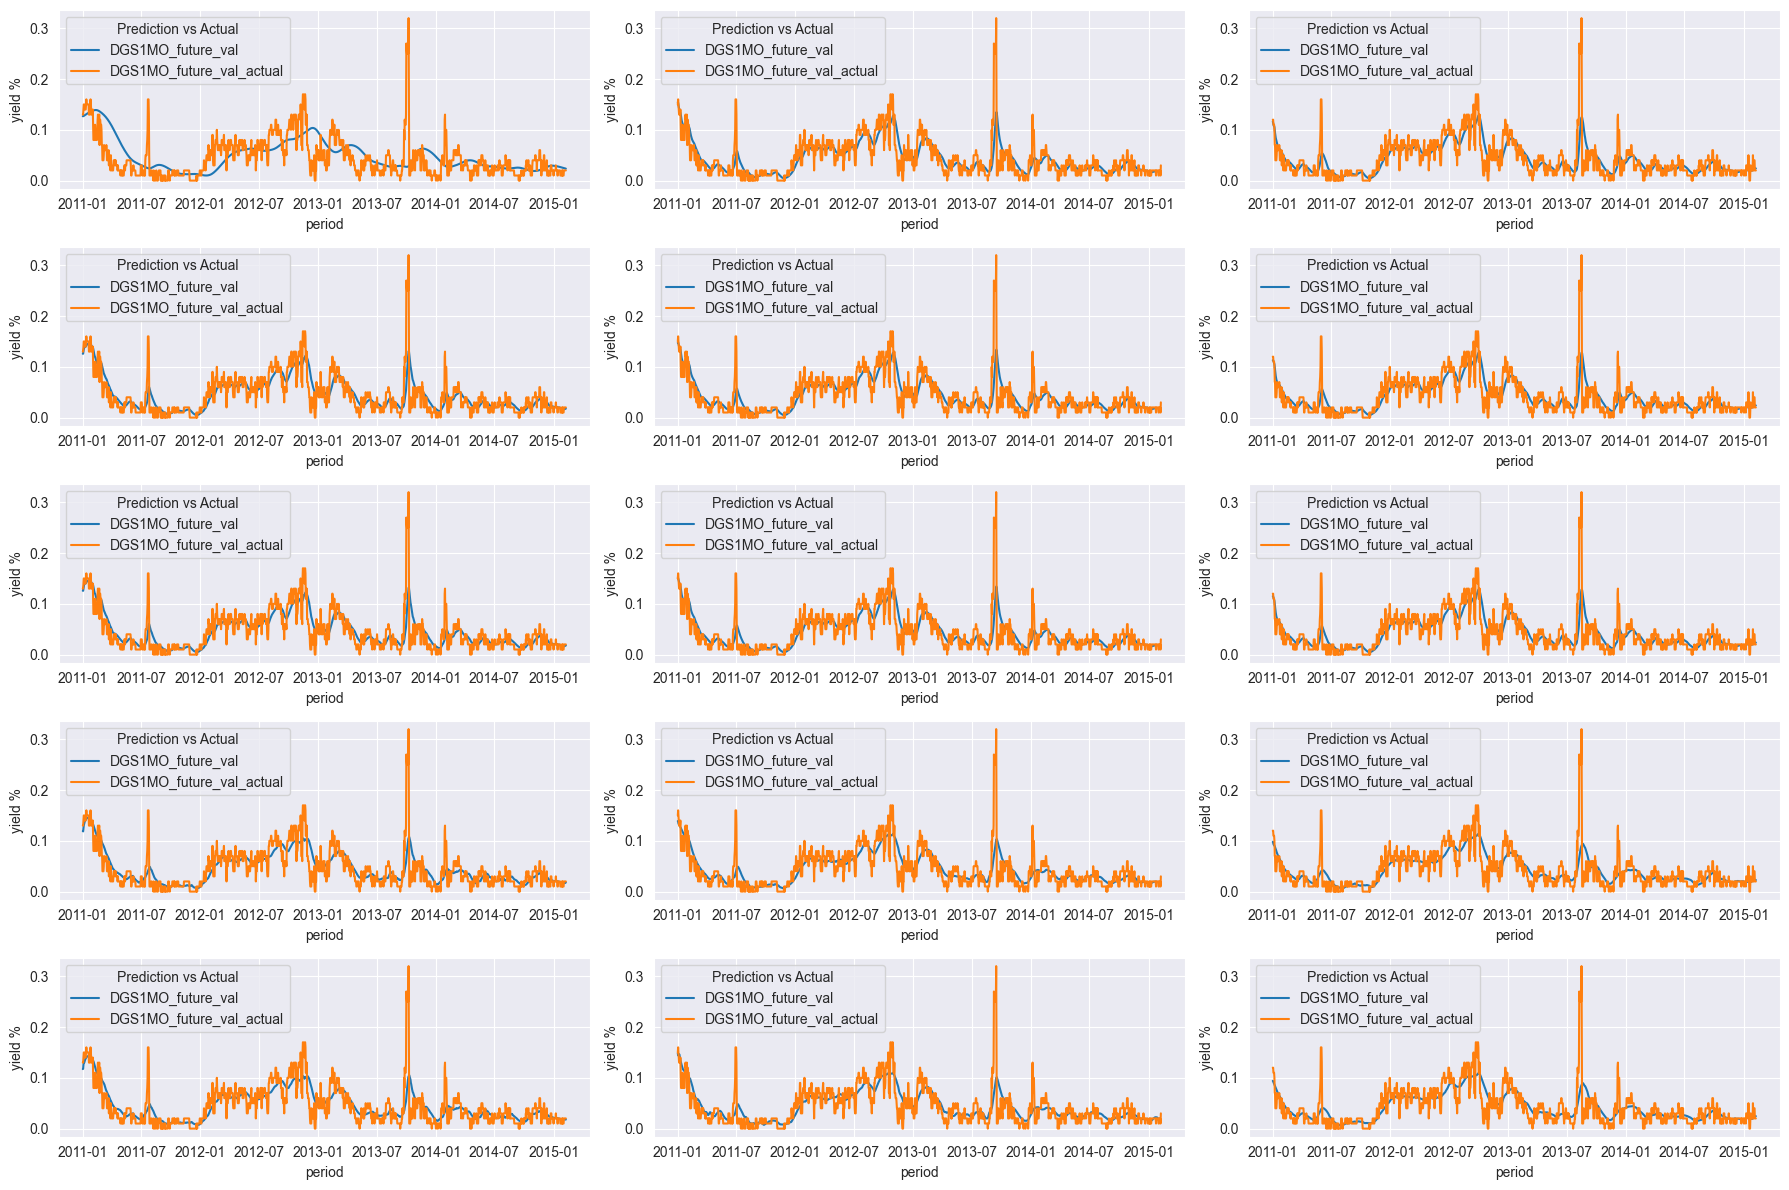

In [19]:
# plot an example bond prediction vs actual with a specified smoothing window
smoothing_window = 30
dgs_value = 'DGS1MO'

# create a 5 by 3 seaborn subplot.The vertical grids represent the 5 kernels and the 3 columns are the time horizons
fig, axes = plt.subplots(5, 3, figsize=(18, 12))
# axes = axes.flatten()
# create grid array
grid_array = [
    models7_predictions_actual,
    models30_predictions_actual,
    models60_predictions_actual
]

for col, predictions in enumerate(grid_array):
    for row, prediction in enumerate(predictions):
        prediction[f"{dgs_value}_future_val"] = prediction[f"{dgs_value}_future_val"].ewm(span=smoothing_window).mean()
        plot_cols = [f"{dgs_value}_future_val", f"{dgs_value}_future_val_actual"]
        df_tmp = prediction[plot_cols].reset_index()
        df_tmp['period'] = df_tmp['period'].apply(lambda x: x.to_timestamp())
        df_tmp = pd.melt(df_tmp, id_vars=['period'], value_vars=plot_cols, var_name='Prediction vs Actual', value_name='yield %')
        sns.lineplot(df_tmp, x='period', y='yield %', hue='Prediction vs Actual', ax=axes[row, col])

plt.tight_layout()
plt.show()

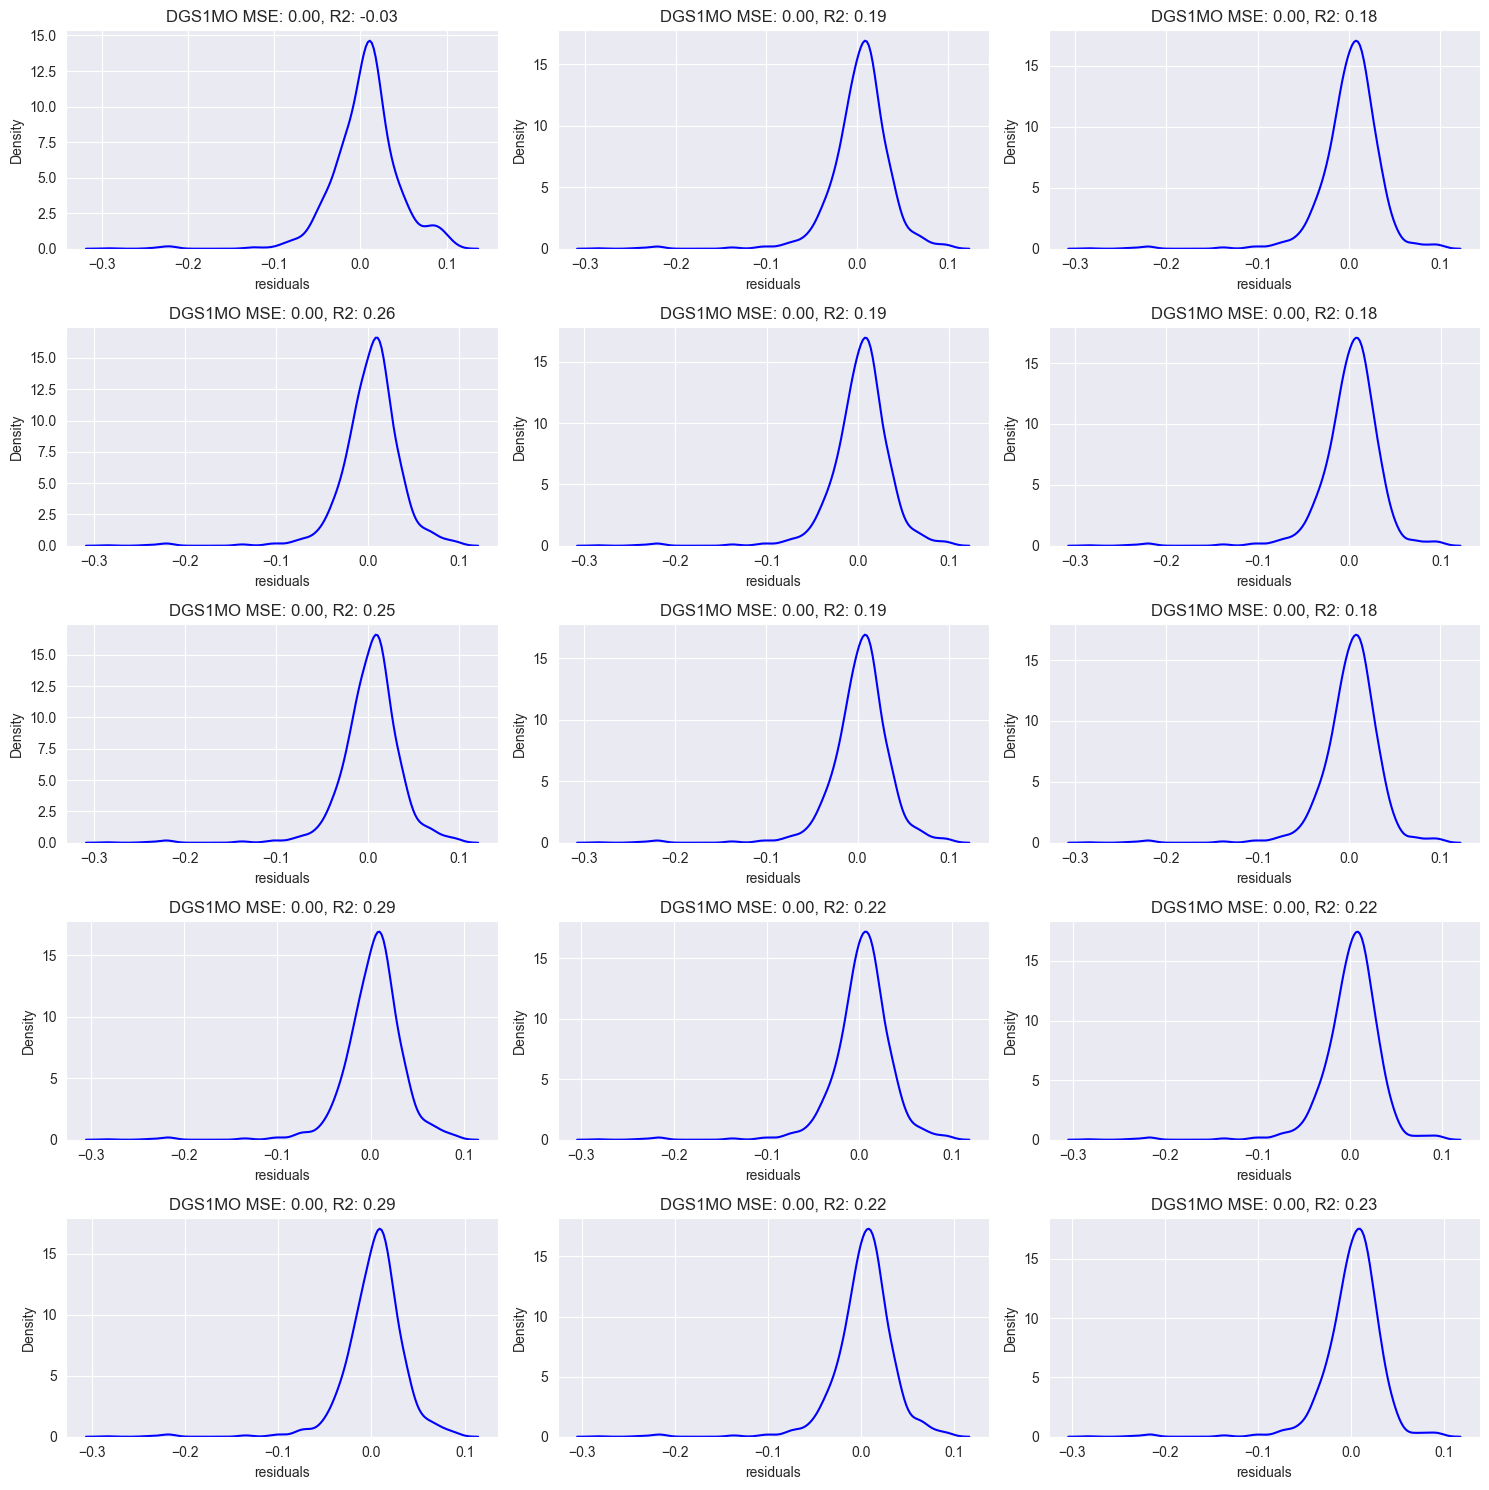

In [22]:
# Calculate the residuals of the results from above, plot a kde distribution of the residuals and calculate the mean squared error.
# create a 5 by 3 seaborn subplot.The vertical grids represent the 5 kernels and the 3 columns are the time horizons
fig, axes = plt.subplots(5, 3, figsize=(15, 15))
# axes = axes.flatten()
# create grid array
grid_array = [
    models7_predictions_actual,
    models30_predictions_actual,
    models60_predictions_actual
]

for col, predictions in enumerate(grid_array):
    for row, prediction in enumerate(predictions):
        prediction[f"{dgs_value}_future_val"] = prediction[f"{dgs_value}_future_val"].ewm(span=smoothing_window).mean()
        prediction['residuals'] = prediction[f"{dgs_value}_future_val"] - prediction[f"{dgs_value}_future_val_actual"]
        # Calclaute the mean squared error and r2 score
        mse = mean_squared_error(prediction[f"{dgs_value}_future_val_actual"], prediction[f"{dgs_value}_future_val"])
        r2 = r2_score(prediction[f"{dgs_value}_future_val_actual"], prediction[f"{dgs_value}_future_val"])
        df_tmp = prediction['residuals'].reset_index()
        sns.kdeplot(df_tmp, x='residuals', color='blue', ax=axes[row, col])
        axes[row, col].set_title(f"{dgs_value} MSE: {mse:.2f}, R2: {r2:.2f}")
plt.tight_layout()
plt.show()

## Training Results

The values for the DGS1MO future values were pretty accurate in the forecasting of the values across all kernels. The training of the model was done on the first 1500 records of our training data. To test out how well it will perform on the validation set, we use the below walk forward approach.
An additional note, the KRR model outputs the Expected dependent variable given the feature set as a point prediction. Given we are trying to understand risk via a distribution of future index yields, we use the below methodology for constructing that distribution.

## Risk Modeling Methodology

The experimental framework employs a walk-forward validation approach that integrates `krr_run.py` and `walk_forward.py` to conduct robust experiments in predicting future index yields while maintaining temporal integrity.

### Experimental Design
The methodology uses a walk-forward validation framework to evaluate kernel ridge regression models for bond yield forecasting. This approach ensures temporal order by training on historical data and testing on future periods, accurately mimicking real-world forecasting scenarios where only past information is available for prediction.

### Model Training and Validation Process

**1. Data Preparation**
- Time series data organized with features at time t predicting yields at t+m (where m ∈ {7, 30, 60} days)
- Features include macroeconomic indicators, yield curve variables, and technical transformations
- StandardScaler applied to normalize feature and target distributions when enabled

**2. Walk-Forward Validation Framework**
- Growing window approach where training window expands over time from minimum window size (2000 observations)
- Model retraining occurs at specified intervals (31 trading days) to adapt to changing market conditions
- Each prediction uses only information available at prediction time to prevent look-ahead bias

**3. Kernel Ridge Regression Ensemble**  
- Multiple kernel functions tested (RBF, Rational Quadratic, Exponential Sine Squared) to capture different market dynamics
- Alpha regularization parameter tuning balances bias-variance tradeoff
- Best performing kernel-alpha combination selected based on validation metrics (R² flat)

**4. Risk Distribution Generation**
- Point predictions provide expected yields E[y|X] 
- Monte Carlo sampling from model posterior generates prediction distributions (1000 samples per prediction)
- Sample distributions provide uncertainty quantification essential for risk assessment
- Prediction boundaries applied to ensure realistic yield ranges

**5. Results and Model Tracking**
- Prediction accuracy tracked through multiple performance metrics
- Model summaries capture hyperparameter selections and feature importance over time
- Sample distributions persisted for downstream risk analysis and portfolio optimization

This methodology enables robust evaluation of bond yield forecasting models while generating the prediction distributions necessary for quantitative risk management and informed investment decision-making.

In [7]:
# implement the walk forward approach on the full training set with a growing window
# independent_variables_7_day.remove('EFFR_exp_moving_avg_30')
time_period_dfs = [
    df_7_day_train, df_30_day_train, df_60_day_train
]
time_period_feature_variables = [
    independent_variables_7_day, independent_variables_30_day, independent_variables_60_day
]
time_period_dependent_variables = [
    dependent_variables_7_day, dependent_variables_30_day, dependent_variables_60_day
]
time_periods = [
    'seven-day-ahead', 'thirty-day-ahead', 'sixty-day-ahead'
]
for df, feature_variables, dependent_variables, time_per in zip(time_period_dfs, time_period_feature_variables, time_period_dependent_variables, time_periods):
    data_loader = BondDataLoader(data_path='data/kernel_regression_train_shifted_30_.parquet') # Data not used as we override the attribute in the next line of code
    data_loader.data = df
    krr_ensemble = KernelRidgeEnsemble(training_metric='r2_flat', random_state=42)
    walk_forward = WalkForwardValidator(
        model=krr_ensemble,
        data_loader=data_loader,
        feature_manager=feature_manager2,
        time_prediction=time_per,
        window_size=1500,
        min_window_size=1500,
        step_size=1,
        model_retrain_interval=31,
        n_parallel_jobs=3,
        use_scaling=True,
        window_type='growing'
    )

    walk_forward.run_walk_forward_validation()
    walk_forward.export_results(filepath=f"results/{time_per}")


INFO:kernel_ridge_models:Created 5 kernel configurations
INFO:kernel_ridge_models:Initialized KRR ensemble with 5 kernels, metric=r2_flat, random_state=42
INFO:walk_forward:Initialized walk-forward validator: window_size=1500, min_window_size=1500, step_size=1
INFO:walk_forward:Starting walk-forward validation for seven-day-ahead
INFO:data_loader:Generated 1057 growing time windows
INFO:walk_forward:Running 800 predictions with 18 features
Running Walk Forward Validation: 100%|██████████| 800/800 [06:49<00:00,  1.95it/s]
INFO:walk_forward:Results exported to results/seven-day-ahead
INFO:kernel_ridge_models:Created 5 kernel configurations
INFO:kernel_ridge_models:Initialized KRR ensemble with 5 kernels, metric=r2_flat, random_state=42
INFO:walk_forward:Initialized walk-forward validator: window_size=1500, min_window_size=1500, step_size=1
INFO:walk_forward:Starting walk-forward validation for thirty-day-ahead
INFO:data_loader:Generated 1057 growing time windows
INFO:walk_forward:Running

In [ ]:
# make plots 2